# AlgoTrade Pro — EMA 50/200 Backtest + ML Signal Filter
### BTC/USDT · 1H · Real Binance Data
---
**Strategy:** EMA 50/200 Golden Cross / Death Cross  
**Data:** Real Binance OHLCV CSV (6 months, 1H candles)  
**ML:** Scikit-learn — classify good vs bad crossover signals  

**Folder structure expected:**
```
your_project/
├── BTCusd_6month_1hr_data/
│   ├── BTCUSDT-1h-2025-09.csv
│   ├── BTCUSDT-1h-2025-10.csv
│   ├── BTCUSDT-1h-2025-11.csv
│   ├── BTCUSDT-1h-2025-12.csv
│   ├── BTCUSDT-1h-2026-01.csv
│   └── BTCUSDT-1h-2026-02.csv
└── algotrade_ema_backtest.ipynb  ← this file
```

## 📦 Cell 1 — Install Dependencies

In [ ]:
# Run this cell once to install required libraries
# !pip install pandas numpy matplotlib scikit-learn seaborn

## 📚 Cell 2 — Imports

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

# ── Chart style ──
plt.rcParams.update({
    'figure.facecolor':  '#060811',
    'axes.facecolor':    '#0b0f1a',
    'axes.edgecolor':    '#1a2235',
    'axes.labelcolor':   '#8892a4',
    'axes.grid':         True,
    'grid.color':        '#1a2235',
    'grid.linewidth':    0.6,
    'text.color':        '#f0f4ff',
    'xtick.color':       '#4a5568',
    'ytick.color':       '#4a5568',
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.facecolor':  '#111827',
    'legend.edgecolor':  '#1a2235',
    'legend.fontsize':   9,
    'font.family':       'monospace',
})

CYAN   = '#00e5c0'
BLUE   = '#3b82f6'
RED    = '#ff4d6d'
YELLOW = '#f59e0b'
PURPLE = '#8b5cf6'
WHITE  = '#f0f4ff'
GRAY   = '#4a5568'

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 📂 Cell 3 — Load & Merge Binance CSV Files

In [4]:
# ── Binance CSV column names ──
BINANCE_COLS = [
    'open_time', 'open', 'high', 'low', 'close', 'volume',
    'close_time', 'quote_volume', 'trades',
    'taker_buy_base', 'taker_buy_quote', 'ignore'
]

DATA_FOLDER = 'BTCusd_6month_1hr_data'

# Find all CSV files in the folder
csv_files = sorted(glob.glob(os.path.join(DATA_FOLDER, '*.csv')))

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files found in '{DATA_FOLDER}/' folder.\n"
        f"Make sure the folder exists and contains Binance CSV files."
    )

print(f'📁 Found {len(csv_files)} CSV files:')
for f in csv_files:
    print(f'   {os.path.basename(f)}')

# Load and merge all files
dfs = []
for f in csv_files:
    tmp = pd.read_csv(f, header=None, names=BINANCE_COLS)
    dfs.append(tmp)

df_raw = pd.concat(dfs, ignore_index=True)

# Parse timestamps — auto detect ms or us
sample_ts = df_raw['open_time'].iloc[0]

if sample_ts > 1e15:
    df_raw['open_time'] = pd.to_datetime(df_raw['open_time'], unit='us')
elif sample_ts > 1e12:
    df_raw['open_time'] = pd.to_datetime(df_raw['open_time'], unit='ms')
else:
    df_raw['open_time'] = pd.to_datetime(df_raw['open_time'], unit='s')

print(f'Timestamp unit auto-detected | Sample: {df_raw["open_time"].iloc[0]}')

df_raw.set_index('open_time', inplace=True)
df_raw.sort_index(inplace=True)

# Keep only OHLCV columns
df_raw = df_raw[['open', 'high', 'low', 'close', 'volume']].astype(float)

# Remove duplicates
df_raw = df_raw[~df_raw.index.duplicated(keep='first')]

print(f'\n✅ Data loaded successfully!')
print(f'   Total candles : {len(df_raw):,}')
print(f'   Date range    : {df_raw.index[0]} → {df_raw.index[-1]}')
print(f'   Price range   : ${df_raw["close"].min():,.2f} → ${df_raw["close"].max():,.2f}')
print(f'\nSample data:')
df_raw.head()

📁 Found 6 CSV files:
   BTCUSDT-1h-2025-09.csv
   BTCUSDT-1h-2025-10.csv
   BTCUSDT-1h-2025-11.csv
   BTCUSDT-1h-2025-12.csv
   BTCUSDT-1h-2026-01.csv
   BTCUSDT-1h-2026-02.csv
Timestamp unit auto-detected | Sample: 2025-09-01 00:00:00

✅ Data loaded successfully!
   Total candles : 4,344
   Date range    : 2025-09-01 00:00:00 → 2026-02-28 23:00:00
   Price range   : $62,900.00 → $126,011.18

Sample data:


,open,high,low,close,volume
open_time,,,,,
2025-09-01 00:00:00,108246.36,108406.18,107631.68,108222.37,1078.82210
2025-09-01 01:00:00,108222.37,108482.98,107968.09,108150.24,471.21562
2025-09-01 02:00:00,108150.24,108197.67,107425.42,107617.05,869.81682
2025-09-01 03:00:00,107617.05,107769.94,107393.00,107660.01,786.48643
2025-09-01 04:00:00,107660.00,107759.99,107279.51,107409.10,645.82838


## 📊 Cell 4 — Calculate Technical Indicators

In [5]:
def add_indicators(df):
    df = df.copy()

    # ── Core EMAs ──
    df['ema_50']  = df['close'].ewm(span=50,  adjust=False).mean()
    df['ema_200'] = df['close'].ewm(span=200, adjust=False).mean()

    # ── EMA spread (gap between EMAs) ──
    df['ema_spread']    = (df['ema_50'] - df['ema_200']) / df['ema_200'] * 100
    df['ema_spread_ch'] = df['ema_spread'].diff()   # rate of spread change

    # ── RSI (14) ──
    delta    = df['close'].diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(span=14, adjust=False).mean()
    avg_loss = loss.ewm(span=14, adjust=False).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    df['rsi'] = 100 - (100 / (1 + rs))

    # ── MACD ──
    ema12         = df['close'].ewm(span=12, adjust=False).mean()
    ema26         = df['close'].ewm(span=26, adjust=False).mean()
    df['macd']    = ema12 - ema26
    df['macd_sig']= df['macd'].ewm(span=9, adjust=False).mean()
    df['macd_hist']= df['macd'] - df['macd_sig']

    # ── ATR (14) ──
    hl  = df['high'] - df['low']
    hcp = (df['high'] - df['close'].shift()).abs()
    lcp = (df['low']  - df['close'].shift()).abs()
    df['atr'] = pd.concat([hl, hcp, lcp], axis=1).max(axis=1).ewm(span=14, adjust=False).mean()
    df['atr_pct'] = df['atr'] / df['close'] * 100   # ATR as % of price

    # ── Bollinger Bands ──
    sma20         = df['close'].rolling(20).mean()
    std20         = df['close'].rolling(20).std()
    df['bb_upper']= sma20 + 2 * std20
    df['bb_lower']= sma20 - 2 * std20
    df['bb_width']= (df['bb_upper'] - df['bb_lower']) / sma20 * 100
    df['bb_pos']  = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])

    # ── Volume indicators ──
    df['vol_sma20']  = df['volume'].rolling(20).mean()
    df['vol_ratio']  = df['volume'] / df['vol_sma20']   # volume vs average

    # ── Price momentum ──
    df['ret_1h']  = df['close'].pct_change(1)  * 100
    df['ret_4h']  = df['close'].pct_change(4)  * 100
    df['ret_24h'] = df['close'].pct_change(24) * 100

    # ── Crossover signals ──
    df['cross_up']   = (df['ema_50'] > df['ema_200']) & (df['ema_50'].shift() <= df['ema_200'].shift())
    df['cross_down'] = (df['ema_50'] < df['ema_200']) & (df['ema_50'].shift() >= df['ema_200'].shift())

    return df.dropna()

df = add_indicators(df_raw)

print('✅ Indicators calculated')
print(f'   Candles after dropna : {len(df):,}')
print(f'   Golden Crosses found : {df["cross_up"].sum()}')
print(f'   Death Crosses found  : {df["cross_down"].sum()}')
df[['close','ema_50','ema_200','rsi','macd','atr','bb_width','vol_ratio']].tail(5)

✅ Indicators calculated
   Candles after dropna : 4,320
   Golden Crosses found : 14
   Death Crosses found  : 15


,close,ema_50,ema_200,rsi,macd,atr,bb_width,vol_ratio
open_time,,,,,,,,
2026-02-28 19:00:00,66362.01,65685.413550,66491.148008,71.652533,-92.841413,803.081891,6.137705,1.130345
2026-02-28 20:00:00,66959.62,65735.382430,66495.809421,76.564238,57.632604,824.146972,6.619441,0.862280
2026-02-28 21:00:00,66723.22,65774.121158,66498.072213,70.952909,156.010450,805.879376,6.970785,0.927652
2026-02-28 22:00:00,67103.64,65826.259152,66504.097763,74.432243,261.656108,851.919459,7.440357,1.232491
2026-02-28 23:00:00,66973.26,65871.239578,66508.766044,71.065960,331.044403,801.832864,7.832046,0.449368


## 📈 Cell 5 — Plot Price + EMA Overview

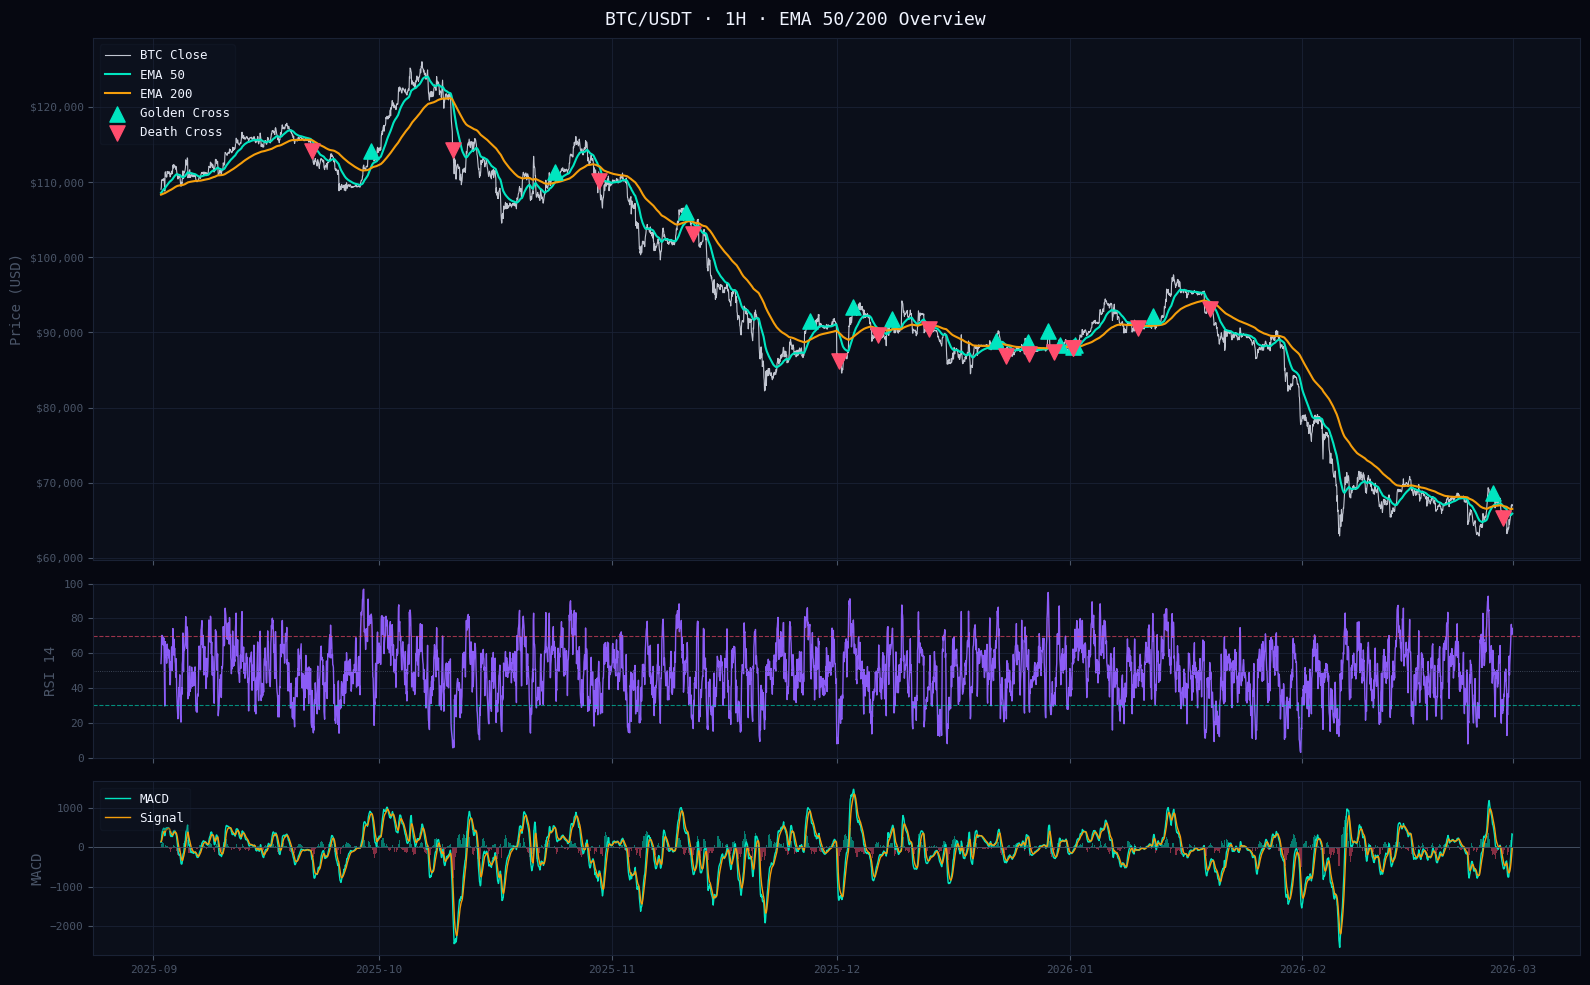

Golden Crosses: 14 | Death Crosses: 15


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1, 1]})
fig.patch.set_facecolor('#060811')
fig.suptitle('BTC/USDT · 1H · EMA 50/200 Overview', color=WHITE, fontsize=13, y=0.98)

# Price + EMAs
ax1 = axes[0]
ax1.plot(df.index, df['close'],   color=WHITE,  lw=0.8, alpha=0.8, label='BTC Close')
ax1.plot(df.index, df['ema_50'],  color=CYAN,   lw=1.5, label='EMA 50')
ax1.plot(df.index, df['ema_200'], color=YELLOW, lw=1.5, label='EMA 200')

# Mark crossovers
golden = df[df['cross_up']]
death  = df[df['cross_down']]
ax1.scatter(golden.index, golden['close'], marker='^', color=CYAN,   s=120, zorder=5, label='Golden Cross')
ax1.scatter(death.index,  death['close'],  marker='v', color=RED,    s=120, zorder=5, label='Death Cross')

ax1.set_ylabel('Price (USD)', color=GRAY)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(loc='upper left', framealpha=0.3)

# RSI
ax2 = axes[1]
ax2.plot(df.index, df['rsi'], color=PURPLE, lw=1.0)
ax2.axhline(70, color=RED,  lw=0.8, ls='--', alpha=0.6)
ax2.axhline(30, color=CYAN, lw=0.8, ls='--', alpha=0.6)
ax2.axhline(50, color=GRAY, lw=0.6, ls=':')
ax2.fill_between(df.index, df['rsi'], 70, where=(df['rsi'] >= 70), alpha=0.15, color=RED)
ax2.fill_between(df.index, df['rsi'], 30, where=(df['rsi'] <= 30), alpha=0.15, color=CYAN)
ax2.set_ylim(0, 100)
ax2.set_ylabel('RSI 14', color=GRAY)

# MACD
ax3 = axes[2]
ax3.plot(df.index, df['macd'],     color=CYAN,  lw=1.0, label='MACD')
ax3.plot(df.index, df['macd_sig'], color=YELLOW,lw=1.0, label='Signal')
ax3.bar(df.index, df['macd_hist'],
        color=[CYAN if v >= 0 else RED for v in df['macd_hist']],
        alpha=0.5, width=0.04)
ax3.axhline(0, color=GRAY, lw=0.6)
ax3.set_ylabel('MACD', color=GRAY)
ax3.legend(loc='upper left', framealpha=0.3)

plt.tight_layout()
plt.show()
print(f'Golden Crosses: {len(golden)} | Death Crosses: {len(death)}')

In [9]:
# Debug cell
# Debug Cell — paste this as a new cell and run it

print(f"Total candles       : {len(df)}")
print(f"Date range          : {df.index[0]} → {df.index[-1]}")
print(f"EMA 50 NaN count    : {df['ema_50'].isna().sum()}")
print(f"EMA 200 NaN count   : {df['ema_200'].isna().sum()}")
print(f"Golden crosses      : {df['cross_up'].sum()}")
print(f"Death crosses       : {df['cross_down'].sum()}")
print()

# Check EMA values
print("Last 5 EMA values:")
print(df[['close','ema_50','ema_200','cross_up','cross_down']].tail(5).to_string())
print()

# Check if EMA 50 ever crosses EMA 200
above = (df['ema_50'] > df['ema_200']).sum()
below = (df['ema_50'] < df['ema_200']).sum()
print(f"Candles where EMA50 > EMA200 : {above}")
print(f"Candles where EMA50 < EMA200 : {below}")

Total candles       : 4320
Date range          : 2025-09-02 00:00:00 → 2026-02-28 23:00:00
EMA 50 NaN count    : 0
EMA 200 NaN count   : 0
Golden crosses      : 14
Death crosses       : 15

Last 5 EMA values:
                        close        ema_50       ema_200  cross_up  cross_down
open_time                                                                      
2026-02-28 19:00:00  66362.01  65685.413550  66491.148008     False       False
2026-02-28 20:00:00  66959.62  65735.382430  66495.809421     False       False
2026-02-28 21:00:00  66723.22  65774.121158  66498.072213     False       False
2026-02-28 22:00:00  67103.64  65826.259152  66504.097763     False       False
2026-02-28 23:00:00  66973.26  65871.239578  66508.766044     False       False

Candles where EMA50 > EMA200 : 1713
Candles where EMA50 < EMA200 : 2607


In [12]:
#Debug
# Deep Debug — run in a new cell

cross_up_times = df[df['cross_up']].index
cross_dn_times = df[df['cross_down']].index

print(f"Golden Cross times ({len(cross_up_times)}):")
for t in cross_up_times:
    row = df.loc[t]
    print(f"  {t} | close={row['close']:.2f} | ema50={row['ema_50']:.2f} | ema200={row['ema_200']:.2f}")

print()
print(f"Death Cross times ({len(cross_dn_times)}):")
for t in cross_dn_times:
    row = df.loc[t]
    print(f"  {t} | close={row['close']:.2f} | ema50={row['ema_50']:.2f} | ema200={row['ema_200']:.2f}")

print()
# Check if backtest loop is even running
print(f"df index type     : {type(df.index)}")
print(f"df index dtype    : {df.index.dtype}")
print(f"First index value : {df.index[0]}")
print(f"Last index value  : {df.index[-1]}")

# Manually check one crossover
ts_test = cross_up_times[0]
row_test = df.loc[ts_test]
print(f"\nManual check on first Golden Cross:")
print(f"  Timestamp  : {ts_test}")
print(f"  cross_up   : {row_test['cross_up']}")
print(f"  type       : {type(row_test['cross_up'])}")
print(f"  bool check : {bool(row_test['cross_up'])}")

Golden Cross times (14):
  2025-09-29 22:00:00 | close=114189.81 | ema50=111843.25 | ema200=111810.45
  2025-10-24 12:00:00 | close=111297.01 | ema50=109973.39 | ema200=109947.49
  2025-11-10 23:00:00 | close=106011.13 | ema50=104724.19 | ema200=104694.58
  2025-11-27 09:00:00 | close=91561.67 | ema50=89041.18 | ema200=88996.25
  2025-12-03 04:00:00 | close=93362.21 | ema50=89443.30 | ema200=89384.24
  2025-12-08 08:00:00 | close=91833.90 | ema50=90384.28 | ema200=90361.92
  2025-12-22 05:00:00 | close=88831.34 | ema50=88272.95 | ema200=88256.30
  2025-12-26 12:00:00 | close=88678.90 | ema50=88093.03 | ema200=88078.34
  2025-12-29 04:00:00 | close=90143.06 | ema50=88012.09 | ema200=87950.67
  2025-12-30 17:00:00 | close=88371.34 | ema50=87941.88 | ema200=87938.89
  2026-01-01 11:00:00 | close=88024.64 | ema50=87996.27 | ema200=87995.69
  2026-01-01 17:00:00 | close=88316.37 | ema50=88004.88 | ema200=87997.76
  2026-01-12 02:00:00 | close=92203.56 | ema50=90880.88 | ema200=90874.48
  20

In [15]:
# Debug 
# Ultimate debug — simulate the loop manually
capital   = 10_000.0
in_trade  = False
stop_loss = 0.0
position  = 0.0
count     = 0

for ts, row in df.iterrows():
    price = float(row['close'])
    
    cross_up   = bool(row['cross_up'])
    cross_down = bool(row['cross_down'])
    
    if cross_up:
        count += 1
        print(f"[{count}] CROSS_UP at {ts}")
        print(f"     price={price:.2f} | in_trade={in_trade} | stop_loss={stop_loss:.2f}")
        
        atr      = float(row['atr'])
        sl       = price - atr * 2.0
        sl_dist  = price - sl
        risk_amt = capital * 0.02
        pos      = risk_amt / sl_dist
        cost     = pos * price * 1.001
        
        print(f"     atr={atr:.2f} | sl={sl:.2f} | sl_dist={sl_dist:.2f}")
        print(f"     position={pos:.6f} | cost={cost:.2f} | capital={capital:.2f}")
        print(f"     cost <= capital? {cost <= capital}")
        
        if count >= 3:
            break

print(f"\nTotal cross_up signals found in loop: {count}")


[1] CROSS_UP at 2025-09-29 22:00:00
     price=114189.81 | in_trade=False | stop_loss=0.00
     atr=425.08 | sl=113339.64 | sl_dist=850.17
     position=0.235248 | cost=26889.82 | capital=10000.00
     cost <= capital? False
[2] CROSS_UP at 2025-10-24 12:00:00
     price=111297.01 | in_trade=False | stop_loss=0.00
     atr=654.64 | sl=109987.73 | sl_dist=1309.28
     position=0.152756 | cost=17018.31 | capital=10000.00
     cost <= capital? False
[3] CROSS_UP at 2025-11-10 23:00:00
     price=106011.13 | in_trade=False | stop_loss=0.00
     atr=666.83 | sl=104677.48 | sl_dist=1333.65
     position=0.149964 | cost=15913.75 | capital=10000.00
     cost <= capital? False

Total cross_up signals found in loop: 3


## 🔁 Cell 6 — Run Rule-Based Backtest (EMA 50/200)

In [16]:
def run_backtest(
    df,
    initial_capital = 10_000.0,
    risk_per_trade  = 0.02,
    atr_sl_mult     = 2.0,
    commission      = 0.001,
):
    capital      = initial_capital
    position     = 0.0
    entry_price  = 0.0
    entry_time   = None
    stop_loss    = 0.0
    trades       = []
    equity_curve = []
    in_trade     = False

    for ts, row in df.iterrows():
        price  = float(row['close'])
        equity = capital + position * price
        equity_curve.append({'timestamp': ts, 'equity': equity, 'price': price})

        # ── Stop Loss Hit ──
        if in_trade and price <= stop_loss:
            pnl      = (price - entry_price) * position
            comm     = price * position * commission
            capital += position * price - comm
            trades.append({
                'entry_time': entry_time, 'exit_time': ts,
                'entry_price': entry_price, 'exit_price': price,
                'pnl': pnl - comm, 'exit_reason': 'STOP LOSS',
                'position': position,
                'duration_h': (ts - entry_time).total_seconds() / 3600
            })
            position = 0.0
            in_trade = False

        # ── Golden Cross → BUY ──
        elif bool(row['cross_up']) and not in_trade:
            atr       = float(row['atr'])
            stop_loss = price - atr * atr_sl_mult
            sl_dist   = price - stop_loss
            risk_amt  = capital * risk_per_trade

            # Risk-based size
            position  = risk_amt / sl_dist

            # Cap: never spend more than 95% of capital
            max_position = (capital * 0.95) / price
            position     = min(position, max_position)

            cost = position * price * (1 + commission)

            if cost <= capital and position > 0:
                capital     -= cost
                entry_price  = price
                entry_time   = ts
                in_trade     = True

        # ── Death Cross → SELL ──
        elif bool(row['cross_down']) and in_trade:
            pnl      = (price - entry_price) * position
            comm     = price * position * commission
            capital += position * price - comm
            trades.append({
                'entry_time': entry_time, 'exit_time': ts,
                'entry_price': entry_price, 'exit_price': price,
                'pnl': pnl - comm, 'exit_reason': 'SIGNAL',
                'position': position,
                'duration_h': (ts - entry_time).total_seconds() / 3600
            })
            position = 0.0
            in_trade = False

    # ── Close open trade at end ──
    if in_trade:
        price    = float(df['close'].iloc[-1])
        pnl      = (price - entry_price) * position
        comm     = price * position * commission
        capital += position * price - comm
        trades.append({
            'entry_time': entry_time, 'exit_time': df.index[-1],
            'entry_price': entry_price, 'exit_price': price,
            'pnl': pnl - comm, 'exit_reason': 'END',
            'position': position,
            'duration_h': (df.index[-1] - entry_time).total_seconds() / 3600
        })

    trades_df = pd.DataFrame(trades)
    equity_df = pd.DataFrame(equity_curve).set_index('timestamp')
    return {
        'trades': trades_df, 'equity': equity_df,
        'final_capital': capital, 'initial_capital': initial_capital
    }


# Run it
result = run_backtest(df)
trades = result['trades']
equity = result['equity']

print(f'✅ Backtest complete')
print(f'   Total trades    : {len(trades)}')
print(f'   Initial capital : ${result["initial_capital"]:,.2f}')
print(f'   Final capital   : ${result["final_capital"]:,.2f}')
if not trades.empty:
    display(trades[['entry_time','exit_time','entry_price','exit_price','pnl','exit_reason','duration_h']])

✅ Backtest complete
   Total trades    : 14
   Initial capital : $10,000.00
   Final capital   : $8,177.10


,entry_time,exit_time,entry_price,exit_price,pnl,exit_reason,duration_h
0,2025-09-29 22:00:00,2025-09-30 09:00:00,114189.81,112781.97,-126.507862,STOP LOSS,11.0
1,2025-10-24 12:00:00,2025-10-30 04:00:00,111297.01,108575.27,-238.301974,STOP LOSS,136.0
2,2025-11-10 23:00:00,2025-11-11 12:00:00,106011.13,104530.83,-136.572711,STOP LOSS,13.0
3,2025-11-27 09:00:00,2025-11-29 17:00:00,91561.67,90421.21,-120.949492,STOP LOSS,56.0
4,2025-12-03 04:00:00,2025-12-05 09:00:00,93362.21,91128.56,-220.959079,STOP LOSS,53.0
5,2025-12-08 08:00:00,2025-12-08 15:00:00,91833.90,89961.37,-184.963641,STOP LOSS,7.0
6,2025-12-22 05:00:00,2025-12-23 05:00:00,88831.34,87765.01,-110.059641,STOP LOSS,24.0
7,2025-12-26 12:00:00,2025-12-26 14:00:00,88678.90,87380.43,-130.628304,STOP LOSS,2.0
8,2025-12-29 04:00:00,2025-12-29 09:00:00,90143.06,88100.05,-194.491120,STOP LOSS,5.0
9,2025-12-30 17:00:00,2026-01-01 10:00:00,88371.34,87863.76,-54.133744,SIGNAL,41.0


In [17]:
#trade log
# Full trade log
print(f"{'#':<4} {'Entry Time':<22} {'Exit Time':<22} {'Entry $':>10} {'Exit $':>10} {'PnL':>10} {'Reason':<12} {'Hours':>8}")
print("-" * 100)
for i, (_, t) in enumerate(trades.iterrows()):
    sign = "+" if t['pnl'] > 0 else ""
    print(f"{i+1:<4} {str(t['entry_time']):<22} {str(t['exit_time']):<22} "
          f"${t['entry_price']:>9,.0f} ${t['exit_price']:>9,.0f} "
          f"{sign}${t['pnl']:>8,.0f}  {t['exit_reason']:<12} {t['duration_h']:>8.1f}h")

print("-" * 100)
print(f"{'TOTAL PnL':>80} ${trades['pnl'].sum():>8,.0f}")

#    Entry Time             Exit Time                 Entry $     Exit $        PnL Reason          Hours
----------------------------------------------------------------------------------------------------
1    2025-09-29 22:00:00    2025-09-30 09:00:00    $  114,190 $  112,782 $    -127  STOP LOSS        11.0h
2    2025-10-24 12:00:00    2025-10-30 04:00:00    $  111,297 $  108,575 $    -238  STOP LOSS       136.0h
3    2025-11-10 23:00:00    2025-11-11 12:00:00    $  106,011 $  104,531 $    -137  STOP LOSS        13.0h
4    2025-11-27 09:00:00    2025-11-29 17:00:00    $   91,562 $   90,421 $    -121  STOP LOSS        56.0h
5    2025-12-03 04:00:00    2025-12-05 09:00:00    $   93,362 $   91,129 $    -221  STOP LOSS        53.0h
6    2025-12-08 08:00:00    2025-12-08 15:00:00    $   91,834 $   89,961 $    -185  STOP LOSS         7.0h
7    2025-12-22 05:00:00    2025-12-23 05:00:00    $   88,831 $   87,765 $    -110  STOP LOSS        24.0h
8    2025-12-26 12:00:00    2025-12-26 14:00

## 📐 Cell 7 — Performance Metrics

In [8]:
def calc_metrics(result):
    trades = result['trades']
    eq     = result['equity']['equity']
    init   = result['initial_capital']
    final  = result['final_capital']

    if trades.empty:
        print('⚠️ No trades generated')
        return {}

    wins   = trades[trades['pnl'] > 0]
    losses = trades[trades['pnl'] <= 0]

    total_pnl     = trades['pnl'].sum()
    win_rate      = len(wins) / len(trades) * 100
    avg_win       = wins['pnl'].mean()   if len(wins)   else 0
    avg_loss      = losses['pnl'].mean() if len(losses) else 0
    gross_profit  = wins['pnl'].sum()    if len(wins)   else 0
    gross_loss    = abs(losses['pnl'].sum()) if len(losses) else 1
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf
    total_return  = (final - init) / init * 100

    # Drawdown
    roll_max = eq.cummax()
    drawdown = (eq - roll_max) / roll_max * 100
    max_dd   = drawdown.min()

    # Sharpe (annualized, 1H → 8760 bars/yr)
    rets   = eq.pct_change().dropna()
    sharpe = (rets.mean() / rets.std()) * np.sqrt(8760) if rets.std() > 0 else 0

    # Calmar
    calmar = (total_return / abs(max_dd)) if max_dd != 0 else 0

    # Expectancy
    expectancy = (win_rate/100 * avg_win) + ((1 - win_rate/100) * avg_loss)

    return {
        'total_trades':   len(trades),
        'winning_trades': len(wins),
        'losing_trades':  len(losses),
        'win_rate':       win_rate,
        'total_pnl':      total_pnl,
        'total_return':   total_return,
        'avg_win':        avg_win,
        'avg_loss':       avg_loss,
        'profit_factor':  profit_factor,
        'max_drawdown':   max_dd,
        'sharpe_ratio':   sharpe,
        'calmar_ratio':   calmar,
        'expectancy':     expectancy,
        'best_trade':     trades['pnl'].max(),
        'worst_trade':    trades['pnl'].min(),
        'avg_duration_h': trades['duration_h'].mean(),
        'sl_hits':        len(trades[trades['exit_reason'] == 'STOP LOSS']),
    }

metrics = calc_metrics(result)

# Pretty print
print('=' * 50)
print('  RULE-BASED EMA 50/200 — PERFORMANCE REPORT')
print('=' * 50)
print(f"  Total Trades     : {metrics['total_trades']}")
print(f"  Win Rate         : {metrics['win_rate']:.1f}%")
print(f"  Total PnL        : ${metrics['total_pnl']:,.2f}")
print(f"  Total Return     : {metrics['total_return']:.2f}%")
print(f"  Sharpe Ratio     : {metrics['sharpe_ratio']:.2f}")
print(f"  Max Drawdown     : {metrics['max_drawdown']:.2f}%")
print(f"  Profit Factor    : {metrics['profit_factor']:.2f}")
print(f"  Avg Win          : ${metrics['avg_win']:,.2f}")
print(f"  Avg Loss         : ${metrics['avg_loss']:,.2f}")
print(f"  Expectancy       : ${metrics['expectancy']:,.2f}")
print(f"  Avg Duration     : {metrics['avg_duration_h']:.1f} hours")
print(f"  Stop Loss Hits   : {metrics['sl_hits']}")
print('=' * 50)

⚠️ No trades generated
  RULE-BASED EMA 50/200 — PERFORMANCE REPORT


KeyError: 'total_trades'

## 📉 Cell 8 — Equity Curve + Drawdown Chart

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})
fig.patch.set_facecolor('#060811')
fig.suptitle('Equity Curve & Drawdown — EMA 50/200 Backtest', color=WHITE, fontsize=12)

eq = equity['equity']

# Equity
ax1.plot(eq.index, eq.values, color=CYAN, lw=1.5, label='Portfolio Value')
ax1.fill_between(eq.index, eq.values, result['initial_capital'],
                 where=(eq.values >= result['initial_capital']),
                 alpha=0.15, color=CYAN)
ax1.fill_between(eq.index, eq.values, result['initial_capital'],
                 where=(eq.values < result['initial_capital']),
                 alpha=0.15, color=RED)
ax1.axhline(result['initial_capital'], color=GRAY, lw=0.8, ls='--', label='Initial Capital')
ax1.set_ylabel('Portfolio Value ($)', color=GRAY)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(framealpha=0.3)

# Drawdown
roll_max = eq.cummax()
dd = (eq - roll_max) / roll_max * 100
ax2.fill_between(dd.index, dd.values, 0, color=RED, alpha=0.5)
ax2.plot(dd.index, dd.values, color=RED, lw=0.8)
ax2.set_ylabel('Drawdown %', color=GRAY)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.show()

## 🤖 Cell 9 — ML Feature Engineering
**Goal:** Train a model to predict whether a crossover signal will be PROFITABLE or not  
Label = 1 (profitable trade) | Label = 0 (losing trade)

In [ ]:
def build_ml_dataset(df, trades):
    """
    For each trade entry, capture market features at signal time.
    Label: 1 = profitable trade, 0 = losing trade
    """
    if trades.empty:
        print('⚠️ No trades to build ML dataset from')
        return pd.DataFrame(), pd.Series()

    features = []
    labels   = []

    for _, trade in trades.iterrows():
        entry_time = trade['entry_time']

        # Get market state at entry
        if entry_time not in df.index:
            continue
        row = df.loc[entry_time]

        feat = {
            # EMA features
            'ema_spread':      row['ema_spread'],
            'ema_spread_ch':   row['ema_spread_ch'],

            # RSI
            'rsi':             row['rsi'],
            'rsi_vs_50':       row['rsi'] - 50,

            # MACD
            'macd':            row['macd'],
            'macd_hist':       row['macd_hist'],
            'macd_vs_signal':  row['macd'] - row['macd_sig'],

            # Volatility
            'atr_pct':         row['atr_pct'],
            'bb_width':        row['bb_width'],
            'bb_pos':          row['bb_pos'],

            # Volume
            'vol_ratio':       row['vol_ratio'],

            # Momentum
            'ret_1h':          row['ret_1h'],
            'ret_4h':          row['ret_4h'],
            'ret_24h':         row['ret_24h'],
        }
        features.append(feat)
        labels.append(1 if trade['pnl'] > 0 else 0)

    X = pd.DataFrame(features)
    y = pd.Series(labels, name='profitable')

    return X, y


X, y = build_ml_dataset(df, trades)

print(f'✅ ML Dataset built')
print(f'   Total samples : {len(X)}')
print(f'   Features      : {list(X.columns)}')
if len(y) > 0:
    print(f'   Profitable    : {y.sum()} ({y.mean()*100:.1f}%)')
    print(f'   Losing        : {(1-y).sum()} ({(1-y).mean()*100:.1f}%)')
X.head()

## 🧠 Cell 10 — Train ML Models (Random Forest + Gradient Boosting)

In [ ]:
if len(X) < 10:
    print('⚠️ Not enough trades for ML training. Need at least 10 trades.')
    print('   Try using more months of data.')
else:
    # Train/test split (80/20, no shuffle — preserve time order)
    split = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    print(f'Train size : {len(X_train)} | Test size : {len(X_test)}')

    # ── Models ──
    models = {
        'Random Forest': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42))
        ]),
        'Gradient Boosting': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42))
        ]),
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  LogisticRegression(random_state=42, max_iter=1000))
        ]),
    }

    results_ml = {}
    print('\n' + '='*50)
    print('  ML MODEL COMPARISON')
    print('='*50)

    for name, pipe in models.items():
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        acc    = accuracy_score(y_test, y_pred)

        # CV score
        cv_scores = cross_val_score(pipe, X, y, cv=min(5, len(X)//2), scoring='accuracy')

        results_ml[name] = {
            'pipeline': pipe,
            'accuracy': acc,
            'cv_mean':  cv_scores.mean(),
            'cv_std':   cv_scores.std(),
            'y_pred':   y_pred
        }
        print(f'  {name}')
        print(f'    Test Accuracy  : {acc*100:.1f}%')
        print(f'    CV Accuracy    : {cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%')
        print()

    # Best model
    best_name = max(results_ml, key=lambda k: results_ml[k]['cv_mean'])
    best_model = results_ml[best_name]['pipeline']
    print(f'🏆 Best Model: {best_name} (CV: {results_ml[best_name]["cv_mean"]*100:.1f}%)')

## 🔍 Cell 11 — Feature Importance

In [ ]:
if len(X) >= 10:
    rf_model = results_ml['Random Forest']['pipeline'].named_steps['model']
    importances = pd.Series(rf_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('#060811')

    colors = [CYAN if v > importances.median() else BLUE for v in importances.values]
    bars = ax.barh(importances.index, importances.values, color=colors, alpha=0.85)

    ax.set_title('Feature Importance — Random Forest', color=WHITE, fontsize=12, pad=10)
    ax.set_xlabel('Importance Score', color=GRAY)
    ax.axvline(importances.median(), color=YELLOW, lw=1, ls='--', alpha=0.6, label='Median')
    ax.legend(framealpha=0.3)

    plt.tight_layout()
    plt.show()

    print('\nTop 5 most important features:')
    print(importances.sort_values(ascending=False).head(5).to_string())

## 🔄 Cell 12 — ML-Filtered Backtest
Only take EMA crossover signals that the ML model predicts as PROFITABLE

In [ ]:
if len(X) >= 10:
    # Build features for ALL crossover signals in the dataset
    cross_up_times = df[df['cross_up']].index

    all_features = []
    all_times    = []

    for ts in cross_up_times:
        row = df.loc[ts]
        feat = {
            'ema_spread':    row['ema_spread'],
            'ema_spread_ch': row['ema_spread_ch'],
            'rsi':           row['rsi'],
            'rsi_vs_50':     row['rsi'] - 50,
            'macd':          row['macd'],
            'macd_hist':     row['macd_hist'],
            'macd_vs_signal':row['macd'] - row['macd_sig'],
            'atr_pct':       row['atr_pct'],
            'bb_width':      row['bb_width'],
            'bb_pos':        row['bb_pos'],
            'vol_ratio':     row['vol_ratio'],
            'ret_1h':        row['ret_1h'],
            'ret_4h':        row['ret_4h'],
            'ret_24h':       row['ret_24h'],
        }
        all_features.append(feat)
        all_times.append(ts)

    if all_features:
        X_all = pd.DataFrame(all_features, index=all_times)
        ml_predictions = pd.Series(
            best_model.predict(X_all),
            index=all_times,
            dtype=bool
        )

        approved = ml_predictions.sum()
        total    = len(ml_predictions)
        print(f'ML Signal Filter: {approved}/{total} signals approved ({approved/total*100:.1f}%)')

        # Run filtered backtest
        result_ml = run_backtest(df, signal_filter=ml_predictions)
        metrics_ml = calc_metrics(result_ml)

        print('\n' + '='*50)
        print('  COMPARISON: Rule-Based vs ML-Filtered')
        print('='*50)
        print(f"  {'Metric':<20} {'Rule-Based':>12} {'ML-Filtered':>12}")
        print(f"  {'-'*44}")
        for key, label in [
            ('total_trades',  'Total Trades'),
            ('win_rate',      'Win Rate %'),
            ('total_return',  'Total Return %'),
            ('sharpe_ratio',  'Sharpe Ratio'),
            ('max_drawdown',  'Max Drawdown %'),
            ('profit_factor', 'Profit Factor'),
        ]:
            v1 = metrics.get(key, 0)
            v2 = metrics_ml.get(key, 0)
            print(f"  {label:<20} {v1:>12.2f} {v2:>12.2f}")
        print('='*50)

## 📊 Cell 13 — Final Comparison Chart

In [ ]:
if len(X) >= 10:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.patch.set_facecolor('#060811')
    fig.suptitle('Rule-Based EMA vs ML-Filtered — Equity Comparison', color=WHITE, fontsize=12)

    eq1 = result['equity']['equity']
    eq2 = result_ml['equity']['equity']

    # Equity curves
    ax = axes[0]
    ax.plot(eq1.index, eq1.values, color=BLUE,  lw=1.5, label='Rule-Based EMA')
    ax.plot(eq2.index, eq2.values, color=CYAN,  lw=1.5, label='ML-Filtered')
    ax.axhline(10000, color=GRAY, lw=0.8, ls='--', alpha=0.5)
    ax.set_title('Equity Curves', color=GRAY, fontsize=10)
    ax.set_ylabel('Portfolio Value ($)', color=GRAY)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend(framealpha=0.3)

    # Metrics bar chart
    ax2 = axes[1]
    metric_names = ['Win Rate %', 'Sharpe', 'Profit Factor']
    vals1 = [metrics['win_rate'], metrics['sharpe_ratio'], metrics['profit_factor']]
    vals2 = [metrics_ml['win_rate'], metrics_ml['sharpe_ratio'], metrics_ml['profit_factor']]

    x = np.arange(len(metric_names))
    w = 0.35
    ax2.bar(x - w/2, vals1, w, color=BLUE,  alpha=0.85, label='Rule-Based')
    ax2.bar(x + w/2, vals2, w, color=CYAN,  alpha=0.85, label='ML-Filtered')
    ax2.set_xticks(x)
    ax2.set_xticklabels(metric_names, color=GRAY)
    ax2.set_title('Key Metrics Comparison', color=GRAY, fontsize=10)
    ax2.axhline(0, color=GRAY, lw=0.6)
    ax2.legend(framealpha=0.3)

    plt.tight_layout()
    plt.show()

## ✅ Cell 14 — Summary & Next Steps

In [ ]:
print('='*55)
print('  ALGOTRADE PRO — BACKTEST COMPLETE')
print('='*55)
print()
print('  WHAT WE DID:')
print('  ✅ Loaded real Binance BTC/USDT 1H CSV data')
print('  ✅ Calculated EMA 50/200, RSI, MACD, ATR, BB')
print('  ✅ Rule-based EMA crossover backtest')
print('  ✅ ML signal filter (Random Forest + GB + LR)')
print('  ✅ Compared rule-based vs ML-filtered results')
print()
print('  NEXT STEPS:')
print('  → Add more strategies (MACD, Bollinger, RSI)')
print('  → Walk-forward optimization (avoid overfitting)')
print('  → Connect Binance API for live paper trading')
print('  → Add risk management (max daily loss, position limits)')
print('  → Deploy the best strategy live')
print('='*55)